In [516]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
import math

display圖片工具

In [517]:
def display_images(img_list, titles, cmap='gray'):
    cols = 3
    rows = math.ceil(len(img_list) / cols)

    fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))
    axes = axes.flatten()

    for i, (img, title) in enumerate(zip(img_list, titles)):
        axes[i].imshow(img, cmap=cmap, vmin=0, vmax=255)
        axes[i].set_title(title)
        axes[i].axis('off')

    # 刪除多於的子畫布
    for i in range(len(img_list), len(axes)):
        axes[i].axis('off')

    # 控制間距
    plt.tight_layout()
    plt.show()

In [518]:
def show_spectrum(H):
    #高頻拉伸
    H = np.log(1 + np.abs(H))
    H = H - H.min()
    H = H / (H.max() + 1e-8) #1e-8避免除以0的情況發生
    return (H * 255).astype(np.uint8)

## 退化-雜訊類

In [519]:
class Noise:
  def apply(self, img):
    raise NotImplementedError("子類別須實作apply")

#高斯雜訊
class GausissionNoise(Noise):
  def __init__(self, mean=0, sigma=20):
    self.mean = mean
    self.sigma = sigma

  def apply(self, img):
    noise = np.random.normal(self.mean, self.sigma, img.shape)
    noisy = img + noise
    return np.clip(noisy, 0, 255).astype(np.uint8)

# 椒鹽雜訊
class SaltPepperNoise(Noise):
  def __init__(self, prob=0.05):
    self.prob = prob
  def apply(self, img):
    noisy = img.copy()
    mask = np.random.rand(*img.shape)
    noisy[mask < self.prob] = 0
    noisy[mask > 1 - self.prob] = 255
    return noisy

# 泊松雜訊
class PoissonNoise(Noise):
    def __init__(self):
        pass

    def apply(self, img):
        # 正規化到 [0,1]
        img_norm = img / 255.0

        # 根據 Poisson 分布產生雜訊
        noisy = np.random.poisson(img_norm * 255) / 255.0

        # 回到 0-255
        noisy = np.clip(noisy * 255, 0, 255).astype(np.uint8)

        return noisy

# 週期性雜訊
class PeriodicNoise(Noise):
    def __init__(self, amplitude=30, freq_x=0.05, freq_y=0.05):
        self.amplitude = amplitude
        self.freq_x = freq_x
        self.freq_y = freq_y

    def apply(self, img):
        rows, cols = img.shape
        x = np.arange(cols)
        y = np.arange(rows)

        xv, yv = np.meshgrid(x, y)

        # 週期性（sin 波）
        periodic = self.amplitude * np.sin(
            2 * np.pi * (self.freq_x * xv + self.freq_y * yv)
        )

        noisy = img.astype(float) + periodic
        return np.clip(noisy, 0, 255).astype(np.uint8)

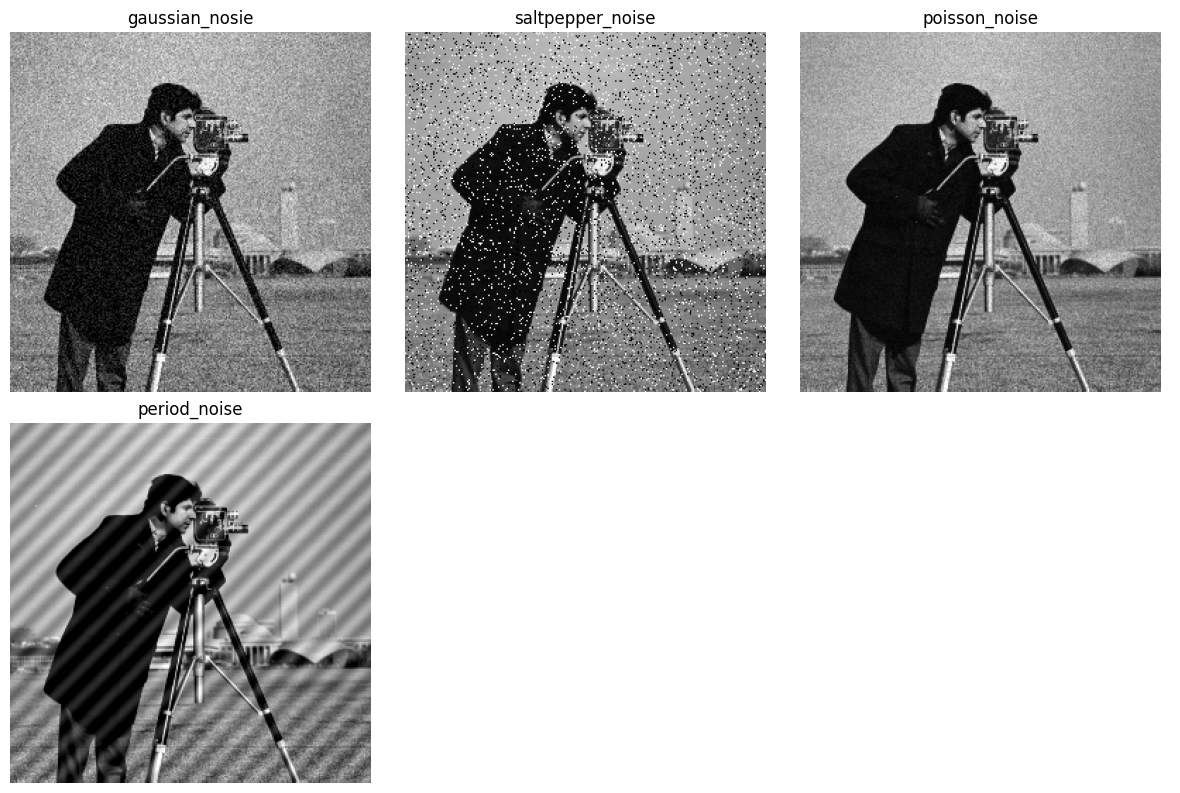

In [520]:
# 測試雜訊
img = cv2.imread("/content/Cameraman.tif", cv2.IMREAD_GRAYSCALE)
gaussian = GausissionNoise(0, 20)
gaussian_img = gaussian.apply(img)

saltpepper = SaltPepperNoise(0.05)
saltpepper_img = saltpepper.apply(img)

poisson = PoissonNoise()
poisson_img = poisson.apply(img)

period = PeriodicNoise()
period_img = period.apply(img)

display_images([gaussian_img, saltpepper_img, poisson_img, period_img], ["gaussian_nosie", "saltpepper_noise", "poisson_noise", "period_noise"])

## 雜訊復原(套件)

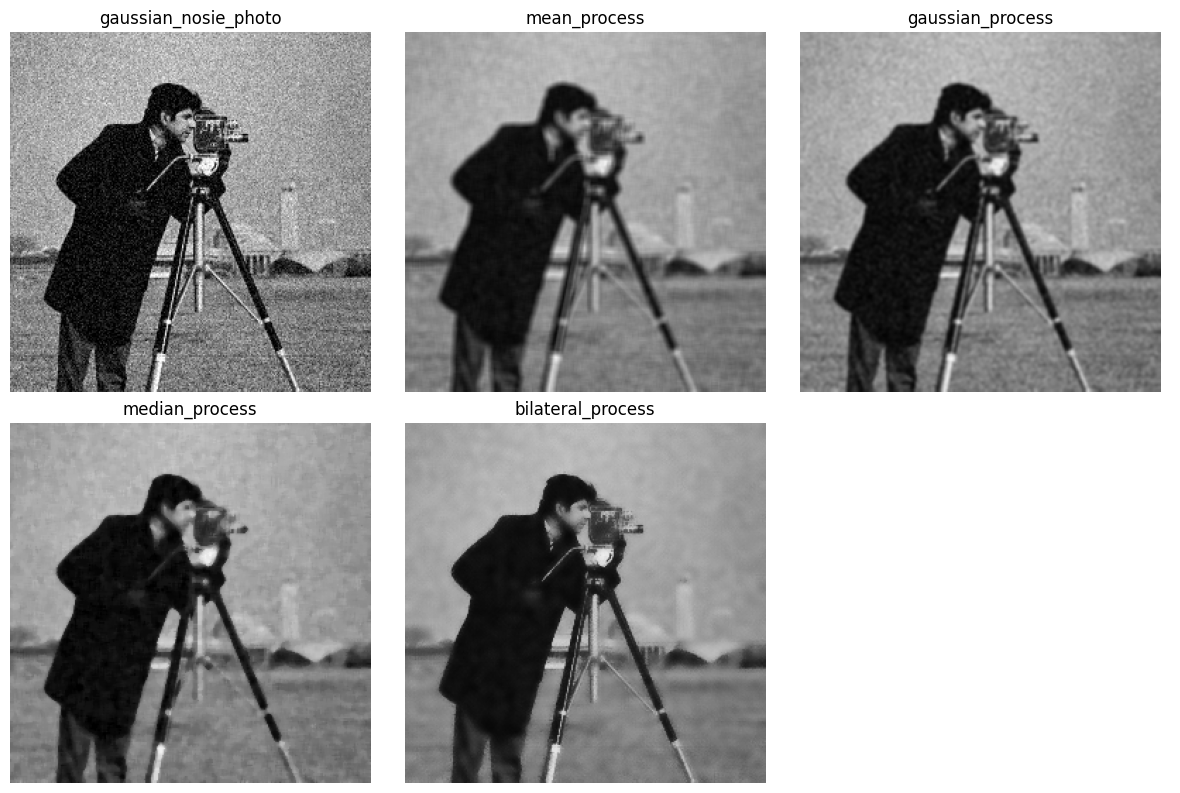

In [521]:
mean_process = cv2.blur(gaussian_img, (5, 5))
gaussian_process = cv2.GaussianBlur(gaussian_img, (5, 5), 0)
median_process = cv2.medianBlur(gaussian_img, 5)
bilateral_process = cv2.bilateralFilter(gaussian_img, 9, 75, 75)

display_images([gaussian_img,mean_process, gaussian_process, median_process, bilateral_process], ["gaussian_nosie_photo","mean_process", "gaussian_process", "median_process", "bilateral_process"])

## 估測退化函數

In [522]:
def get_motion_blur_H(shape, length=20, angle=0):
    M, N = shape
    H = np.zeros((M, N), dtype=np.float32)

    center = (N // 2, M // 2)
    angle_rad = np.deg2rad(angle)

    dx = int((length / 2) * np.cos(angle_rad))
    dy = int((length / 2) * np.sin(angle_rad))

    # draw line kernel
    cv2.line(H, (center[0] - dx, center[1] - dy),
                (center[0] + dx, center[1] + dy), 1, 1)

    # normalize
    H = H / np.sum(H)

    # FFT to get degradation function
    H = np.fft.fftshift(np.fft.fft2(H))

    return H

In [523]:
def get_atmospheric_H(shape, k=0.0025):
    M, N = shape
    u = np.arange(M) - M // 2
    v = np.arange(N) - N // 2
    U, V = np.meshgrid(u, v)

    D2 = U**2 + V**2
    H = np.exp(-k * (D2 ** (5/6)))   # Kolmogorov turbulence
    return H

In [524]:
def apply_freq_filter(img, H):
    F = np.fft.fft2(img)
    F_shift = np.fft.fftshift(F)

    G_shift = F_shift * H

    # Back to spatial domain
    g = np.fft.ifft2(np.fft.ifftshift(G_shift))
    g = np.abs(g)

    # normalize 0–255 (avoid black image)
    g = g - g.min()
    g = g / (g.max() + 1e-12)
    g = (g * 255).astype(np.uint8)

    return g

In [525]:
def wiener_filter(G, H, K=0.001):
    H_conj = np.conj(H)
    F_hat = (H_conj / (np.abs(H)**2 + K)) * G
    return F_hat

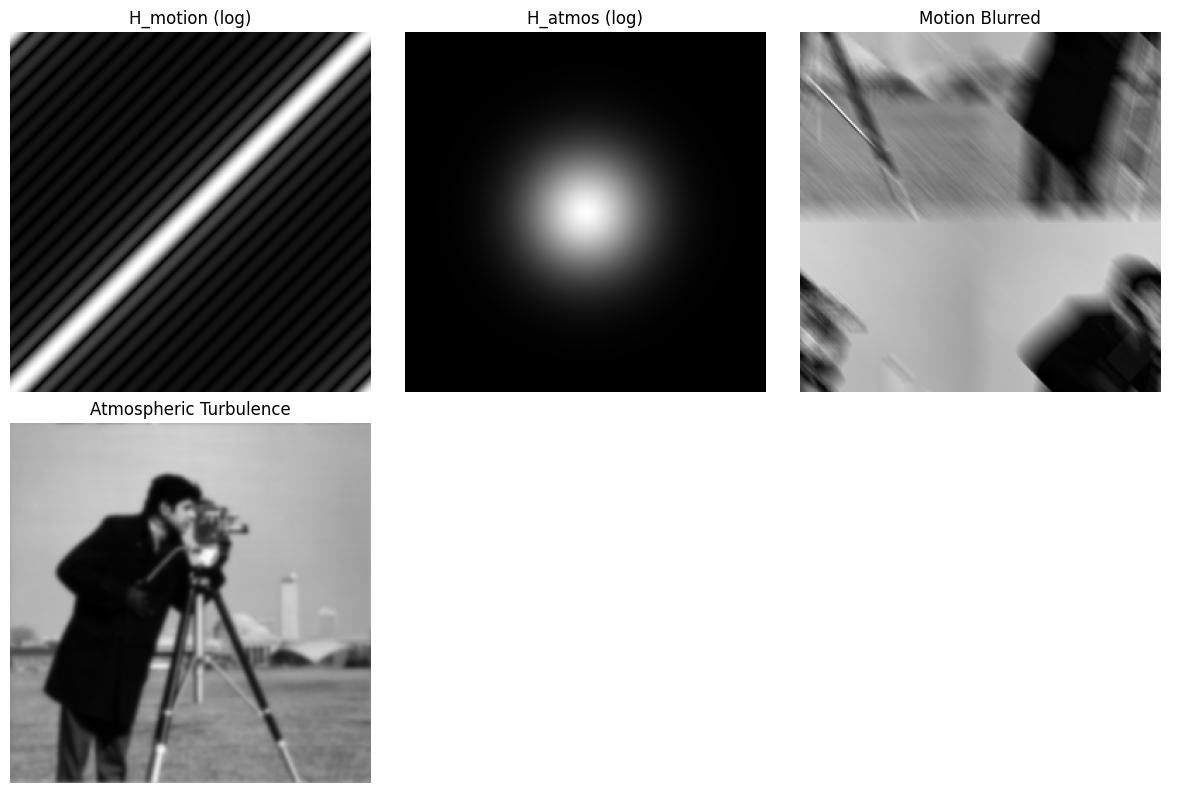

In [526]:
# Load image
img = cv2.imread("/content/Cameraman.tif", cv2.IMREAD_GRAYSCALE).astype(np.float32)

shape = img.shape

# Create two degradation functions
H_motion = get_motion_blur_H(shape, length=25, angle=45)
H_atmos  = get_atmospheric_H(shape, k=0.0025)

H_motion_show = show_spectrum(H_motion)
H_atmos_show  = show_spectrum(H_atmos)


# Apply degradation
img_motion = apply_freq_filter(img, H_motion)
img_atmos  = apply_freq_filter(img, H_atmos)

# Display degradations
display_images(
    [H_motion_show, H_atmos_show, img_motion, img_atmos],
    ["H_motion (log)", "H_atmos (log)", "Motion Blurred", "Atmospheric Turbulence"]
)

In [527]:
print("H_motion range:", H_motion.min(), H_motion.max())
print("H_atmos range:", H_atmos.min(), H_atmos.max())

print("H_motion_show range:", H_motion_show.min(), H_motion_show.max())
print("H_atmos_show range:", H_atmos_show.min(), H_atmos_show.max())


H_motion range: (-0.9927869-5.551115e-17j) (1+4.8572257e-17j)
H_atmos range: 5.137408514451786e-07 1.0
H_motion_show range: 0 255
H_atmos_show range: 0 254


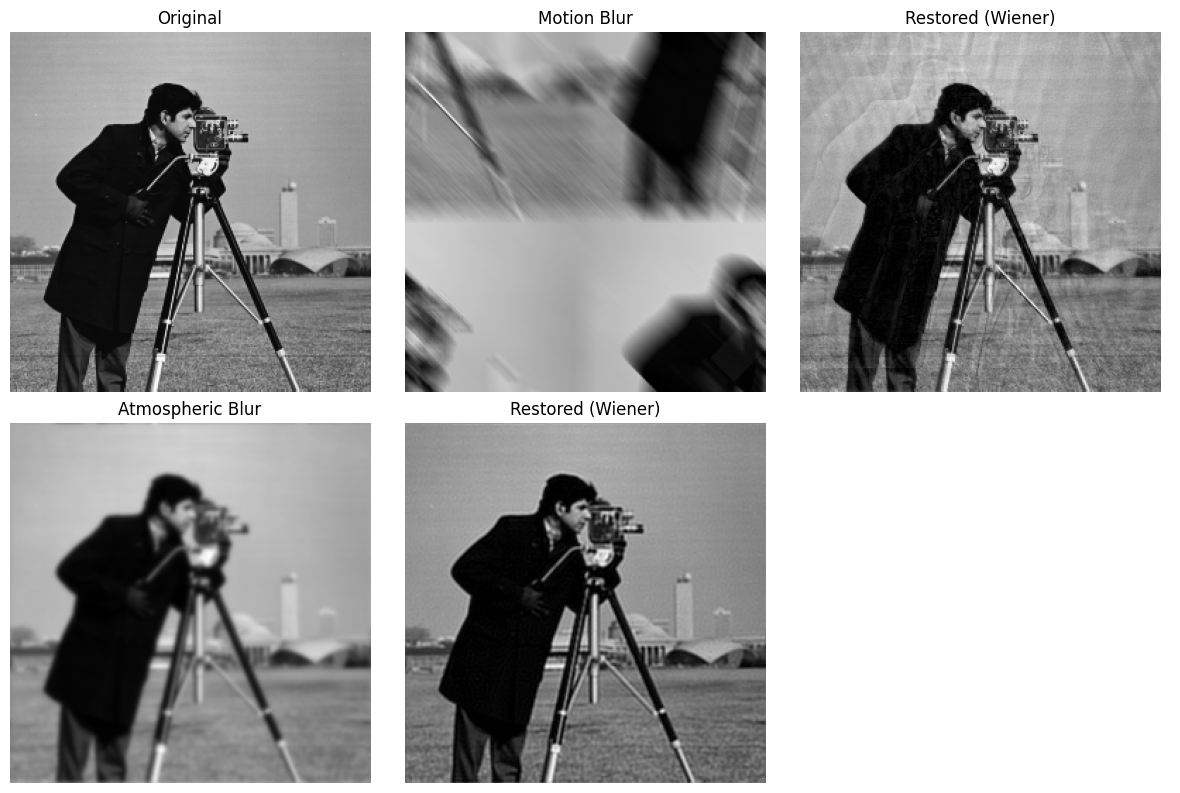

In [528]:
# Frequency transform of degraded images
G_motion = np.fft.fftshift(np.fft.fft2(img_motion))
G_atmos  = np.fft.fftshift(np.fft.fft2(img_atmos))

# Wiener filtering
F_motion = wiener_filter(G_motion, H_motion, K=0.001)
F_atmos  = wiener_filter(G_atmos, H_atmos, K=0.001)

# Back to spatial
rest_motion = np.abs(np.fft.ifft2(np.fft.ifftshift(F_motion)))
rest_atmos  = np.abs(np.fft.ifft2(np.fft.ifftshift(F_atmos)))

# Normalize + uint8
rest_motion = (255 * (rest_motion - rest_motion.min()) /
               (rest_motion.max() - rest_motion.min())).astype(np.uint8)
rest_atmos  = (255 * (rest_atmos - rest_atmos.min()) /
               (rest_atmos.max() - rest_atmos.min())).astype(np.uint8)

display_images(
    [img, img_motion, rest_motion, img_atmos, rest_atmos],
    ["Original",
     "Motion Blur",
     "Restored (Wiener)",
     "Atmospheric Blur",
     "Restored (Wiener)"]
)